In [23]:
import itertools
import time
from typing import TypeAlias, Any, Callable, ParamSpec, Concatenate
from collections.abc import Sequence

import numpy as np
import numpy.linalg as npla
import numpy.random as npr
import numpy.typing as npt

from scipy import integrate as intg
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.colors as clr
import matplotlib.cm as cm

import pynumdiff as ndiff  # Some submodules requrie cvxpy or tqdm
from pynumdiff import smooth_finite_difference as smoothfd
from pynumdiff import polynomial_fit as polyfit
from pynumdiff import basis_fit as basisfit
from pynumdiff import optimize as ndiffopt
from pynumdiff.utils import evaluate as ndiffeval
import pysindy as ps
import sys

import importlib
import mysindy

importlib.reload(mysindy)  # Force reloading module to apply changes

<module 'mysindy' from 'c:\\Users\\yq\\Seafile\\Sync\\Documents\\University of Washington\\2026 Q1 Winter\\ME 571 Data-Driven Dynamic Systems\\ME 571 Final Project\\SINDY-Noise-Investigation\\mysindy.py'>

# Databook excerpt

Dynamical system

$$
\gdef \d { \mathrm{d} }
\gdef \od #1#2{ \frac{\d#1}{\d#2} }
\gdef \b #1{ \boldsymbol{#1} }

\od{\b x}{t} = \b f(\b x), \quad \b x \in \R^n
$$

is represented in SINDy as

$$
\gdef \brm #1{ \mathbf{#1} }

\brm{\dot X} = \b\Theta(\brm X) \, \b\Xi,
$$

where

$$ \begin{aligned}
\gdef \T { \mathsf{T} }
\gdef \arraystretch { 1.2 }

\brm X
&=
    \begin{bmatrix} \b x(t_1)^\T \\ \vdots \\ \, \b x(t_m)^\T \, \end{bmatrix}
    \in \R^{m \times n},
\\[5ex]
\b\Theta(\brm X)
&=
    \begin{bmatrix}
        \,\b 1_{n \times 1} & \b\Phi_1(\brm X) & \cdots & \b\Phi_j(\brm X) & \cdots~
    \end{bmatrix}
    \in \R^{m \times L}.
\end{aligned} $$

Functions
$\gdef \b #1{ \boldsymbol{#1} }$
$\gdef \brm #1{ \mathbf{#1} }$
$\b\Phi_j(\brm X) \in \R^{m \times \ell_j}$
are defined as

$$
\def \arraystretch {1.4}

\b\Phi_j(\brm X) =
    \begin{bmatrix}
        \b\phi_j \bigl[ \b x(t_1) \bigr]^\T \\
        \vdots \\
        \, \b\phi_j \bigl[ \b x(t_m) \bigr]^\T \,
    \end{bmatrix},
\quad
\b\phi_j(\b x) \in \R^{\ell_j}.
$$

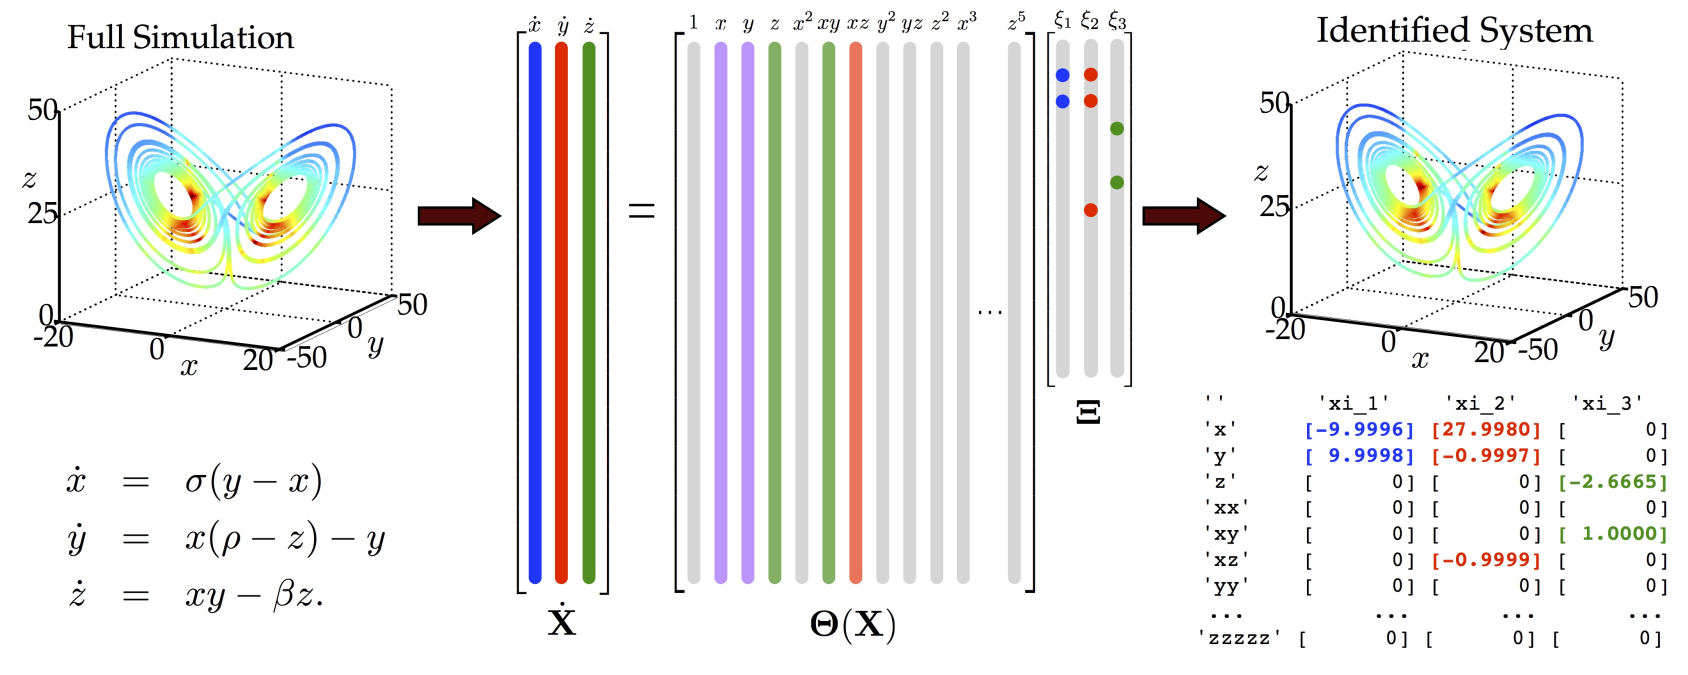

We look for a sparse solution

$$
\gdef \b #1{ \boldsymbol{#1} }

\b\Xi =
    \begin{bmatrix} \, \b\xi_1 & \cdots & \b\xi_n \, \end{bmatrix} \in \R^{L \times n}
$$

such that each column $\b\xi_k$ is sparse. This solution may be found through a convex $\ell_1$-regularized sparse regression:

$$
\gdef \brm #1{ \mathbf{#1} }

\b\xi_k =
    \argmin_{\b\xi}
        \Bigl[
            \bigl\lVert \b{\dot x}_k - \b\Theta(\brm X) \, \b\xi \bigr\rVert_2
            + \lambda \bigl\lVert \b\xi \bigr\rVert_1
        \Bigr].
$$

# STLS

One of such regression algorithms is sequentially thresholded least squares (STLS). It is illustrated by this code snippet:

In [ ]:
def stls(
    lib: mysindy.FloatData,
    x_dot: mysindy.FloatArr,
    threshold: float,
    *,
    max_iter: int = 100
) -> mysindy.FloatArr:
    m, ell = lib.shape
    n = x_dot.shape[1]

    # Initial guess: Least-squares
    sol = npla.lstsq(lib, x_dot, rcond=None)[0]
    mask = np.ones((ell, n), dtype=bool)

    iter: int = 0
    for iter in range(max_iter):
        # Find small coefficients
        mask_new = np.abs(sol) >= threshold
        # Break if mask does not change between iterations
        if np.array_equal(mask_new, mask):
            # print(f"threshold: {threshold}")
            # print()
            # print(sol)
            # print()
            # print(mask_new)
            break
        mask = mask_new

        sol[~mask] = 0  # and threshold
        for k in range(n):
            nonzero = mask[:, k]

            # Skip update if all entries of sol are small
            if not np.any(nonzero):
                continue

            sub_lib = lib[:, nonzero]
            # If underdetermined, lstsq will use dense minimum-norm solution, so skip
            if npla.matrix_rank(sub_lib) < nonzero.sum():
                continue

            # Regress onto remaining terms
            sol[nonzero, k] = npla.lstsq(sub_lib, x_dot[:, k], rcond=None)[0]

    print(f"Exited at {iter} iterations.")

    return sol

With this algorithm and Lorenz 63 model, we can build a SINDy demo.

Observation:

When we used `dt = 1e-2` and `num_steps = 3 * 10**4`, with no scaling and `threshold = 0.7`, the SINDy algorithm could not sufficiently approximate the true parameters. 

```
dt = 1e-2
num_steps = 3 * 10**4
threshold = 0.7
[[  0.           0.           0.        ]
 [ -9.90350115 -11.03049726   0.        ]
 [  9.90728667   9.89652171   0.        ]
 [  0.           0.          -2.15336835]
 [  0.           0.           1.29867123]
 [  0.           0.          -1.32011388]
 [  0.           0.           0.        ]
 [  0.           0.           0.90810394]
 [  0.           0.           0.        ]
 [  0.           0.           0.        ]]
```

The accuracy improved substantially with `dt = 1e-3` and `num_steps = 3 * 10**4`:

```
dt = 1e-3
num_steps = 3 * 10**4
threshold = 0.7
[[  0.           0.           0.        ]
 [-10.01651722  27.27786475   0.        ]
 [ 10.02490981  -0.7909272    0.        ]
 [  0.           0.          -2.66397368]
 [  0.           0.           0.        ]
 [  0.           0.           0.99334565]
 [  0.          -0.98136189   0.        ]
 [  0.           0.           0.        ]
 [  0.           0.           0.        ]
 [  0.           0.           0.        ]]
```

For `num_steps = 3 * 10**5`:

```
dt = 1e-3
num_steps = 3 * 10**5
threshold = 0.7
[[ 0.          0.          0.        ]
 [-9.96680891 25.41077808  0.        ]
 [ 9.97280289  0.          0.        ]
 [ 0.          0.         -2.66480088]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.99896428]
 [ 0.         -0.94554063  0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]]
```

This causes `sol[2, 1]` to diminish, when its ground truth value should be `1`.

We believe that this indicates `threshold` is too large. Changing it to `0.3` yields a much better result:

```
dt = 1e-3
num_steps = 3 * 10**5
threshold = 0.3
[[ 0.          0.          0.        ]
 [-9.96680891 27.68296409  0.        ]
 [ 9.97280289 -0.92295433  0.        ]
 [ 0.          0.         -2.66480088]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.99896428]
 [ 0.         -0.99049465  0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]]
```

Now we go back to `3 * 10**4` steps. The estimation is indeed worse than the `3 * 10**5` steps run:

```
dt = 1e-3
num_steps = 3 * 10**4
threshold = 0.3
[[  0.           0.           0.60637425]
 [-10.01651722  27.27786475   0.        ]
 [ 10.02490981  -0.7909272    0.        ]
 [  0.           0.          -2.68662789]
 [  0.           0.           0.        ]
 [  0.           0.           0.99333602]
 [  0.          -0.98136189   0.        ]
 [  0.           0.           0.        ]
 [  0.           0.           0.        ]
 [  0.           0.           0.        ]]
```

We find it interesting that the best threshold seems to vary with size of samples.

We observe that the two most fragile coefficients are `sol[2, 1]` and `sol[0, 2]`, corresponding to the $-y$ term in $\frac{\mathrm{d}y}{\mathrm{d}t}$ and the zero constant term in $\frac{\mathrm{d}z}{\mathrm{d}t}$.

In [136]:
# Generate Lorenz attractor trajectory
dt = 1e-3
num_steps = 3 * 10**4
x_0 = np.array([0, 2, 8])
traj = mysindy.Trajectory(mysindy.lorenz, x_0, dt, num_steps, noise_std=1)

In [137]:
# Build a library
lib = mysindy.library_function(traj.x_denoised.transpose(), 2, df=False)

In [138]:
# Run SINDy
threshold = 0.3 # sparsification knob lambda
sol = stls(lib, traj.x_dot_denoised.transpose(), threshold)

Exited at 2 iterations.


In [139]:
print(sol)

[[  0.           0.           0.60637425]
 [-10.01651722  27.27786475   0.        ]
 [ 10.02490981  -0.7909272    0.        ]
 [  0.           0.          -2.68662789]
 [  0.           0.           0.        ]
 [  0.           0.           0.99333602]
 [  0.          -0.98136189   0.        ]
 [  0.           0.           0.        ]
 [  0.           0.           0.        ]
 [  0.           0.           0.        ]]


## Ground truth

In [140]:
lib = mysindy.library_function(traj.x.transpose(), 2, df=False)

threshold = 0.7 # sparsification knob lambda
print(stls(lib, traj.x_dot.transpose(), threshold))

Exited at 1 iterations.
[[  0.           0.           0.        ]
 [-10.          28.           0.        ]
 [ 10.          -1.           0.        ]
 [  0.           0.          -2.66666667]
 [  0.           0.           0.        ]
 [  0.           0.           1.        ]
 [  0.          -1.           0.        ]
 [  0.           0.           0.        ]
 [  0.           0.           0.        ]
 [  0.           0.           0.        ]]


## Noisy `x`, denoised `x_dot`

In [148]:
# Generate Lorenz attractor trajectory
dt = 1e-3
num_steps = 3 * 10**5
x_0 = np.array([0, 2, 8])
traj = mysindy.Trajectory(mysindy.lorenz, x_0, dt, num_steps, noise_std=0.7)

# Build a library
lib = mysindy.library_function(traj.x_noisy.transpose(), 2, df=False)

# Run SINDy
threshold = 0.3 # sparsification knob lambda
sol = stls(lib, traj.x_dot_denoised.transpose(), threshold)
print(sol)

Exited at 2 iterations.
[[ 0.          0.         -0.43555938]
 [-9.42805165 25.66581104  0.        ]
 [ 9.50322393 -0.32054911  0.        ]
 [ 0.          0.         -2.61726185]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.98781939]
 [ 0.         -0.94422915  0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]]
